In [188]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Binarizer
from sklearn.decomposition import PCA
import random

In [189]:
random.seed(1)
data_ = pd.read_csv(r"C:\Users\ashto\OneDrive\Documents\Python\Aprendizado_de_maquina\data\iris-with-errors.csv")
data_.head(25)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,duplicada
1,5.1,3.5,1.4,0.2,duplicada
2,?,3,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,5.1,3.5,1.4,0.2,duplicada
5,NaN,3.1,1.5,0.2,setosa
6,5,3.6,1.4,0.2,setosa
7,5.4,3.9,1.7,0.4,duplicada
8,5.4,3.9,1.7,0.4,duplicada
9,4.6,3.4,1.4,NaN,setosa


#### Tratamento da base (nan, valores incoerentes, duplicatas)

In [190]:
data = data_.dropna() # tira os nan
data = data.drop_duplicates()
data = data.replace('?',np.nan)
data = data.dropna()
data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,duplicada
3,4.7,3.2,1.3,0.2,setosa
6,5,3.6,1.4,0.2,setosa
7,5.4,3.9,1.7,0.4,duplicada
10,5,3.4,1.5,0.2,setosa
11,4.4,2.9,1.4,0.2,duplicada
12,4.9,3.1,1.5,0.1,setosa
13,5.4,3.7,1.5,0.2,setosa
15,4.8,3.4,1.6,0.2,setosa
16,4.8,3,1.4,0.1,setosa


#### Substituindo Nan pelas respectivas médias

In [191]:
data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,duplicada
3,4.7,3.2,1.3,0.2,setosa
6,5,3.6,1.4,0.2,setosa
7,5.4,3.9,1.7,0.4,duplicada
10,5,3.4,1.5,0.2,setosa
11,4.4,2.9,1.4,0.2,duplicada
12,4.9,3.1,1.5,0.1,setosa
13,5.4,3.7,1.5,0.2,setosa
15,4.8,3.4,1.6,0.2,setosa
16,4.8,3,1.4,0.1,setosa


In [117]:
data = data_.replace("?", np.nan)
X = np.array(data[data.columns[0:data.shape[1]-1]] , dtype = float) # pega todas as colunas menos a ultima e transforma em matriz
averages = np.nanmean(X, axis = 0)
for i in np.arange(0, X.shape[0]):
    for j in np.arange(0,X.shape[1]):
        if (np.isnan(X[i,j]) == True):
            X[i,j] = averages[j]
X

array([[5.1       , 3.5       , 1.4       , 0.2       ],
       [5.1       , 3.5       , 1.4       , 0.2       ],
       [5.02272727, 3.        , 1.4       , 0.2       ],
       [4.7       , 3.2       , 1.3       , 0.2       ],
       [5.1       , 3.5       , 1.4       , 0.2       ],
       [5.02272727, 3.1       , 1.5       , 0.2       ],
       [5.        , 3.6       , 1.4       , 0.2       ],
       [5.4       , 3.9       , 1.7       , 0.4       ],
       [5.4       , 3.9       , 1.7       , 0.4       ],
       [4.6       , 3.4       , 1.4       , 0.22608696],
       [5.        , 3.4       , 1.5       , 0.2       ],
       [4.4       , 2.9       , 1.4       , 0.2       ],
       [4.9       , 3.1       , 1.5       , 0.1       ],
       [5.4       , 3.7       , 1.5       , 0.2       ],
       [4.4       , 2.9       , 1.4       , 0.2       ],
       [4.8       , 3.4       , 1.6       , 0.2       ],
       [4.8       , 3.        , 1.4       , 0.1       ],
       [4.4       , 2.9       ,

#### Normalização

In [118]:
data = pd.read_csv(r"C:\Users\ashto\OneDrive\Documents\Python\Aprendizado_de_maquina\data\iris.csv", header = (0))
X = np.array(data[data.columns[0:data.shape[1]-1]], dtype = float)
for i in range(X.shape[1]):
    print("Maior valor da coluna", i, max(X[:,i]))
    print("Menor valor da coluna", i, min(X[:,i]))

scaler = MinMaxScaler(feature_range = (0,1)) # definindo o minimo e o max
X_norm = scaler.fit_transform(X)
X_norm

Maior valor da coluna 0 7.9
Menor valor da coluna 0 4.3
Maior valor da coluna 1 4.4
Menor valor da coluna 1 2.0
Maior valor da coluna 2 6.9
Menor valor da coluna 2 1.0
Maior valor da coluna 3 2.5
Menor valor da coluna 3 0.1


array([[0.22222222, 0.625     , 0.06779661, 0.04166667],
       [0.16666667, 0.41666667, 0.06779661, 0.04166667],
       [0.11111111, 0.5       , 0.05084746, 0.04166667],
       [0.08333333, 0.45833333, 0.08474576, 0.04166667],
       [0.19444444, 0.66666667, 0.06779661, 0.04166667],
       [0.30555556, 0.79166667, 0.11864407, 0.125     ],
       [0.08333333, 0.58333333, 0.06779661, 0.08333333],
       [0.19444444, 0.58333333, 0.08474576, 0.04166667],
       [0.02777778, 0.375     , 0.06779661, 0.04166667],
       [0.16666667, 0.45833333, 0.08474576, 0.        ],
       [0.30555556, 0.70833333, 0.08474576, 0.04166667],
       [0.13888889, 0.58333333, 0.10169492, 0.04166667],
       [0.13888889, 0.41666667, 0.06779661, 0.        ],
       [0.        , 0.41666667, 0.01694915, 0.        ],
       [0.41666667, 0.83333333, 0.03389831, 0.04166667],
       [0.38888889, 1.        , 0.08474576, 0.125     ],
       [0.30555556, 0.79166667, 0.05084746, 0.125     ],
       [0.22222222, 0.625     ,

In [119]:
print("Maior valor da coluna", np.amax(X_norm,axis =0))
print("Menor valor da coluna", np.amin(X_norm,axis =0))

Maior valor da coluna [1. 1. 1. 1.]
Menor valor da coluna [0. 0. 0. 0.]


#### Normalização com (alt + 230) µ = 0 e (Alt + 229) σ² = 1

In [120]:
X = np.array(data[data.columns[:data.shape[1]-1]], dtype = float)
scaler = StandardScaler().fit(X)
rescaledX = scaler.transform(X)
rescaledX

array([[-9.00681170e-01,  1.03205722e+00, -1.34127240e+00,
        -1.31297673e+00],
       [-1.14301691e+00, -1.24957601e-01, -1.34127240e+00,
        -1.31297673e+00],
       [-1.38535265e+00,  3.37848329e-01, -1.39813811e+00,
        -1.31297673e+00],
       [-1.50652052e+00,  1.06445364e-01, -1.28440670e+00,
        -1.31297673e+00],
       [-1.02184904e+00,  1.26346019e+00, -1.34127240e+00,
        -1.31297673e+00],
       [-5.37177559e-01,  1.95766909e+00, -1.17067529e+00,
        -1.05003079e+00],
       [-1.50652052e+00,  8.00654259e-01, -1.34127240e+00,
        -1.18150376e+00],
       [-1.02184904e+00,  8.00654259e-01, -1.28440670e+00,
        -1.31297673e+00],
       [-1.74885626e+00, -3.56360566e-01, -1.34127240e+00,
        -1.31297673e+00],
       [-1.14301691e+00,  1.06445364e-01, -1.28440670e+00,
        -1.44444970e+00],
       [-5.37177559e-01,  1.49486315e+00, -1.28440670e+00,
        -1.31297673e+00],
       [-1.26418478e+00,  8.00654259e-01, -1.22754100e+00,
      

In [ ]:
for i in np.arange(0, rescaledX.shape[1]):
    print("Média da coluna", i, np.mean(rescaledX[:,i]))
    print("Desvio padrão da coluna", i, np.std(rescaledX[:,i]),'\n')µ

Média da coluna 0 -4.736951571734001e-16
Desvio padrão da coluna 0 1.0 

Média da coluna 1 -6.631732200427602e-16
Desvio padrão da coluna 1 0.9999999999999999 

Média da coluna 2 3.315866100213801e-16
Desvio padrão da coluna 2 0.9999999999999998 

Média da coluna 3 -2.842170943040401e-16
Desvio padrão da coluna 3 1.0 



#### Binarização dos dados

In [122]:
X = np.array(data[data.columns[:data.shape[1]-1]], dtype = float)
T = 0.2 # valor do limiar

scaler = MinMaxScaler(feature_range= (0,1))
X_pad = scaler.fit_transform(X)
binarizer = Binarizer(threshold= T).fit(X_pad) # o fit é para calcular o limiar e o transform é para aplicar a transformação
binaryX = binarizer.transform(X_pad)
for i in np.arange(0, binaryX.shape[1]):
	print("Antes", X_pad[i,])
	print("Depois", binaryX[i,],'\n')


Antes [0.22222222 0.625      0.06779661 0.04166667]
Depois [1. 1. 0. 0.] 

Antes [0.16666667 0.41666667 0.06779661 0.04166667]
Depois [0. 1. 0. 0.] 

Antes [0.11111111 0.5        0.05084746 0.04166667]
Depois [0. 1. 0. 0.] 

Antes [0.08333333 0.45833333 0.08474576 0.04166667]
Depois [0. 1. 0. 0.] 



#### Conversão de variáveis nominais em inteiros

In [123]:
data = pd.read_csv(r"C:\Users\ashto\OneDrive\Documents\Python\Aprendizado_de_maquina\data\iris.csv", header = (0))
data[data.columns[-1]]

0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: species, Length: 150, dtype: object

In [124]:
classes = np.unique(data[data.columns[-1]])
number = 0
for i in classes:
    data = data.replace(i,number)
    number = number + 1
print(data[data.columns[-1]])

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: species, Length: 150, dtype: int64


C:\Users\ashto\AppData\Local\Temp\ipykernel_14680\3972380960.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace(i,number)


#### One-hot encolding


In [125]:
data = pd.read_csv(r"C:\Users\ashto\OneDrive\Documents\Python\Aprendizado_de_maquina\data\iris.csv", header = (0))
df = pd.get_dummies(data, columns=["species"], dtype=int)
df

,sepal_length,sepal_width,petal_length,petal_width,species_setosa,species_versicolor,species_virginica
0,5.1,3.5,1.4,0.2,1,0,0
1,4.9,3.0,1.4,0.2,1,0,0
2,4.7,3.2,1.3,0.2,1,0,0
3,4.6,3.1,1.5,0.2,1,0,0
4,5.0,3.6,1.4,0.2,1,0,0
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,0,0,1
146,6.3,2.5,5.0,1.9,0,0,1
147,6.5,3.0,5.2,2.0,0,0,1
148,6.2,3.4,5.4,2.3,0,0,1


#### Dados correlacionados

In [126]:
data = pd.read_csv(r"C:\Users\ashto\OneDrive\Documents\Python\Aprendizado_de_maquina\data\BostonHousing.csv", header = (0))
data.head(10)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,386.71,17.10,18.9


<Axes: >

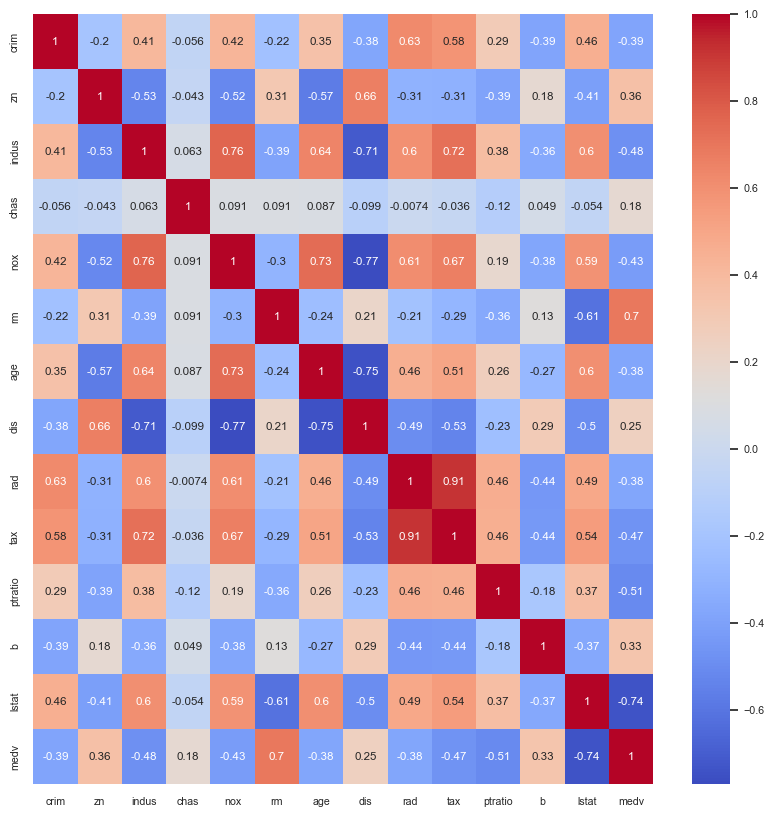

In [127]:
corr = data.corr()
plt.figure(figsize=(10,10)) # define o tamanho da figura
sns.set(font_scale=0.7) # define o tamanho da fonte
sns.heatmap(
    corr, 
    annot = True, # mostra os valores da correlação
    cmap =  "coolwarm" # define o mapa de cores como 
    )# define o mapa de cores

In [128]:
p = 0.75

var = []

for i in corr.columns:
    for j in corr.columns:
        if (i != j):
            if np.abs(corr[i][j]) > p:
                var.append([i,j])
                
print(var)
# se tivermos uma correlação bem alta como 0.75, consideramos apenas uma das variáveis, pois elas estão muito relacionadas e podem causar problemas de multicolinearidade.

[['indus', 'nox'], ['nox', 'indus'], ['nox', 'dis'], ['dis', 'nox'], ['rad', 'tax'], ['tax', 'rad']]


#### Dados desbalanceados

In [129]:
data = pd.read_csv(r"data/Vehicle.csv", header = (0))
data

,Comp,Circ,D.Circ,Rad.Ra,Pr.Axis.Ra,Max.L.Ra,Scat.Ra,Elong,Pr.Axis.Rect,Max.L.Rect,Sc.Var.Maxis,Sc.Var.maxis,Ra.Gyr,Skew.Maxis,Skew.maxis,Kurt.maxis,Kurt.Maxis,Holl.Ra,Class
0,95,48,83,178,72,10,162,42,20,159,176,379,184,70,6,16,187,197,van
1,91,41,84,141,57,9,149,45,19,143,170,330,158,72,9,14,189,199,van
2,104,50,106,209,66,10,207,32,23,158,223,635,220,73,14,9,188,196,saab
3,93,41,82,159,63,9,144,46,19,143,160,309,127,63,6,10,199,207,van
4,85,44,70,205,103,52,149,45,19,144,241,325,188,127,9,11,180,183,bus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
841,93,39,87,183,64,8,169,40,20,134,200,422,149,72,7,25,188,195,saab
842,89,46,84,163,66,11,159,43,20,159,173,368,176,72,1,20,186,197,van
843,106,54,101,222,67,12,222,30,25,173,228,721,200,70,3,4,187,201,saab
844,86,36,78,146,58,7,135,50,18,124,155,270,148,66,0,25,190,195,saab


In [130]:
# contagem do número de classes
classes = data[data.columns[-1]]
cl = np.unique(classes)
ncl = np.zeros(len(cl))
for i in np.arange(0,len(cl)):
    a = classes == cl[i] 
    ncl[i] = a.sum()
    
print(ncl)

[218. 212. 217. 199.]


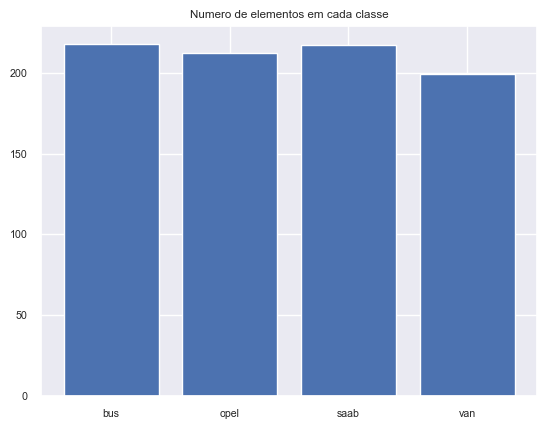

In [131]:
numbers = np.arange(0,len(cl))
plt.bar(numbers, ncl)
plt.xticks(numbers, cl)
plt.title("Numero de elementos em cada classe")
plt.show(True)

In [144]:
print(data["Class"].value_counts(normalize=True) * 100)
data.count()

Class
bus     25.768322
saab    25.650118
opel    25.059102
van     23.522459
Name: proportion, dtype: float64


Comp            846
Circ            846
D.Circ          846
Rad.Ra          846
Pr.Axis.Ra      846
Max.L.Ra        846
Scat.Ra         846
Elong           846
Pr.Axis.Rect    846
Max.L.Rect      846
Sc.Var.Maxis    846
Sc.Var.maxis    846
Ra.Gyr          846
Skew.Maxis      846
Skew.maxis      846
Kurt.maxis      846
Kurt.Maxis      846
Holl.Ra         846
Class           846
dtype: int64

In [148]:
# Para redistribuir os dados de modo que cada classe contenha o mesmo numero de elementos
# Vamos balancear os dados de forma que cada classe contenha N elementos. escolheremos N elementos de forma aleatória, sem reposição, de cada classe

N = 3
cl = np.unique(classes)
X = np.array(data)
Xnew = []
cls = np.array(data[data.columns[-1]])

for i in np.arange(0, len(cl)):
    a = np.argwhere(cls == cl[i]) # pega os indices dos elementos da classe i
    inds = np.random.choice(a[:,0], N, replace = False) #  escolhe N indices de forma aleatoria, sem reposição, da classe i
    # print(inds)
    Xnew.append(X[inds,:])

Xnew = np.array(Xnew)
print(Xnew)

# len(cl)


[[[98 46 88 191 63 6 192 34 22 147 215 563 174 73 2 26 194 197 'bus']
  [94 43 64 173 69 7 150 43 19 142 169 344 177 68 9 1 199 206 'bus']
  [98 46 77 199 71 7 166 39 20 150 184 422 180 69 13 9 200 203 'bus']]

 [[95 43 96 202 65 10 189 35 22 143 217 534 166 71 6 27 190 197 'opel']
  [89 38 78 153 61 7 146 46 19 127 166 314 142 69 0 9 187 194 'opel']
  [102 54 100 163 53 10 213 31 24 173 219 669 201 76 12 27 187 195
   'opel']]

 [[89 38 77 161 62 7 149 45 19 129 174 327 153 71 6 21 188 193 'saab']
  [106 53 98 193 60 10 215 31 24 169 224 681 218 73 8 21 188 197 'saab']
  [108 54 105 203 62 11 202 33 23 164 216 608 235 68 12 3 190 200 'saab']]

 [[88 36 53 113 57 3 118 57 17 128 137 204 136 88 7 14 180 183 'van']
  [86 35 44 110 54 2 119 57 17 121 139 208 137 90 6 1 180 183 'van']
  [94 49 87 137 54 11 158 43 20 162 178 366 186 75 5 5 183 194 'van']]]


#### Boxplot

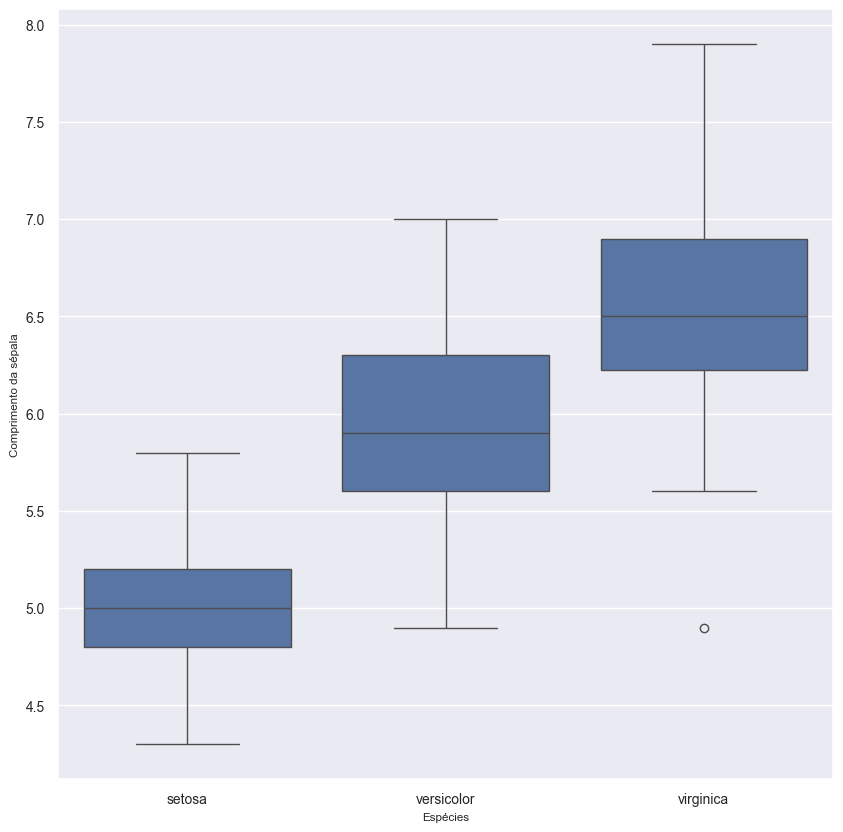

In [153]:
data= pd.read_csv(r"C:\Users\ashto\OneDrive\Documents\Python\Aprendizado_de_maquina\data\iris.csv", header = (0))
plt.figure(figsize = (10,10))
sns.boxplot(x = "species", y = "sepal_length", data = data)
plt.xlabel("Espécies")
plt.ylabel("Comprimento da sépala")
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)
plt.show(True)

In [ ]:
np.random.seed(101)
# Gerando um DataFrame com valores aleatórios entre 1 e 200, com 20 linhas e 3 colunas
data = pd.DataFrame({'a' : np.random.randint(1,200,20),
                     'b': np.random.randint(1,200,20),
                     'c': np.random.randint(1,200,20)})

data[data > 150] = data[data>150]*10
print(data)

       a     b     c
0     96   112   100
1     12   137    29
2     82   116    64
3     71  1580     8
4     64   116   139
5     88    60  1810
6     76  1630  1850
7    138    45   104
8     41    73    39
9    133    20    74
10    64   127  1810
11  1690   139   147
12    61    77    72
13  1930   108   104
14   111    88   144
15     6   129    45
16   141   106     1
17    41     9   117
18    50    63   107
19    84  1650   141


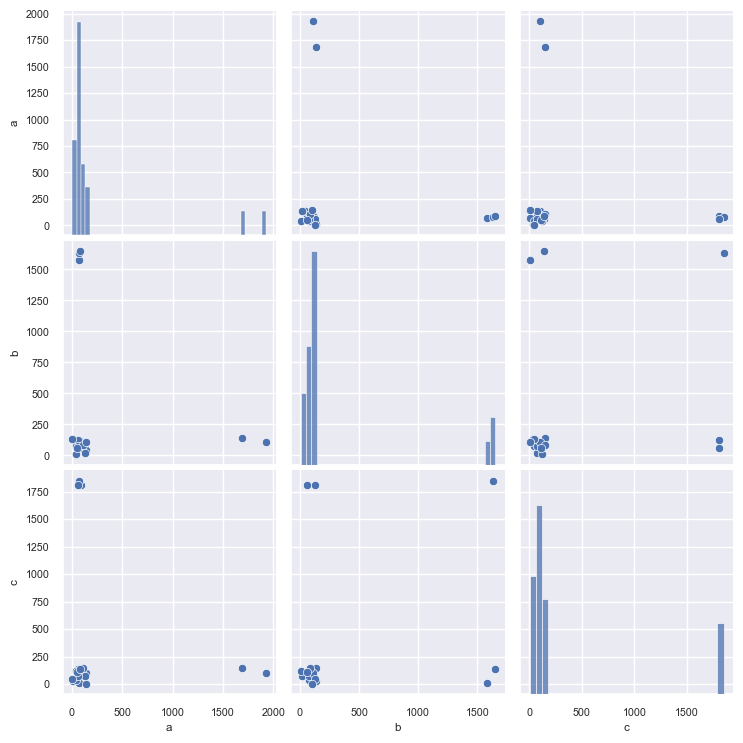

In [157]:
sns.pairplot(data)
plt.show()

In [159]:
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

print(((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))))

        a      b      c
0   False  False  False
1   False  False  False
2   False  False  False
3   False   True  False
4   False  False  False
5   False  False   True
6   False   True   True
7   False  False  False
8   False  False  False
9   False  False  False
10  False  False   True
11   True  False  False
12  False  False  False
13   True  False  False
14  False  False  False
15  False  False  False
16  False  False  False
17  False  False  False
18  False  False  False
19  False   True  False


In [165]:
v = ((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).any(axis = 1)
data = data.drop(data.index[list(v)], axis = 0)
data

,a,b,c
0,96,112,100
1,12,137,29
2,82,116,64
4,64,116,139
7,138,45,104
8,41,73,39
9,133,20,74
12,61,77,72
14,111,88,144
15,6,129,45


#### Análise dos componentes principais

In [ ]:
data = pd.read_csv(r"C:\Users\ashto\OneDrive\Documents\Python\Aprendizado_de_maquina\data\iris.csv", header = (0))
classes = np.unique(data[data.columns[-1]])
print(data.shape)
list_labels = list(data.columns)

data = data.to_numpy()
nrow, ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1] # pega todas as colunas menos a ultima e transforma em matriz

(150, 5)


In [180]:
# normalização dos dados
scaler = StandardScaler().fit(X)
X = scaler.transform(X) # normaliza os dados para que tenham média 0 e desvio padrão 1

pca = PCA(n_components = 2) # o n_components é o número de componentes principais que queremos manter. Ele deve ser menor que o número de variáveis originais. Ele é usado para reduzir a dimensionalidade dos dados, mantendo a maior parte da variância dos dados.
pca_result = pca.fit_transform(X) # aplica a transformação PCA nos dados normalizados

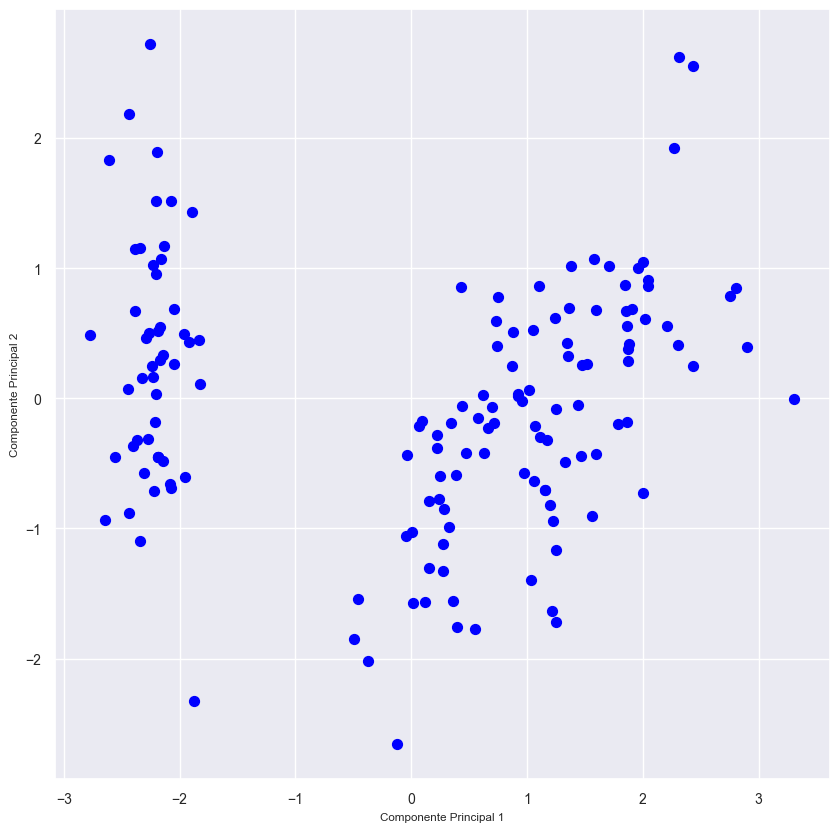

In [182]:
plt.figure(figsize = (10,10))
plt.scatter(pca_result[:,0], pca_result[:,1], s= 50, color = "blue")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)
plt.show()

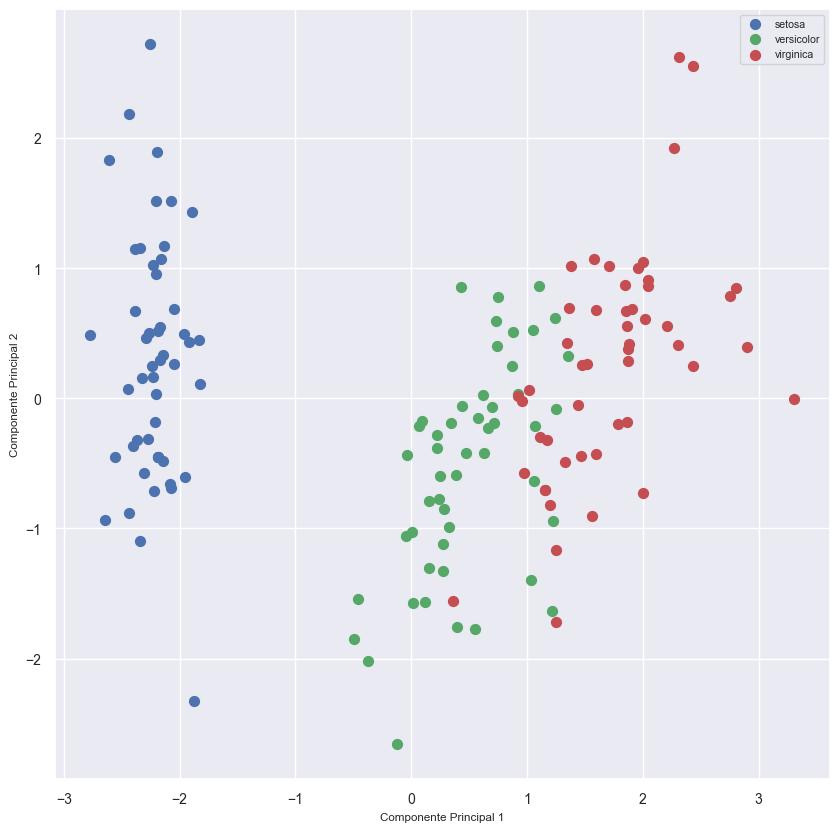

In [185]:
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k','w']
aux = 0
plt.figure(figsize = (10,10))

for c in classes:
    nodes = np.where(y == c)
    plt.scatter(pca_result[nodes,0], pca_result[nodes,1], s = 50, color = colors[aux], label = c)
    aux = aux + 1
    
plt.legend()
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)
plt.show()



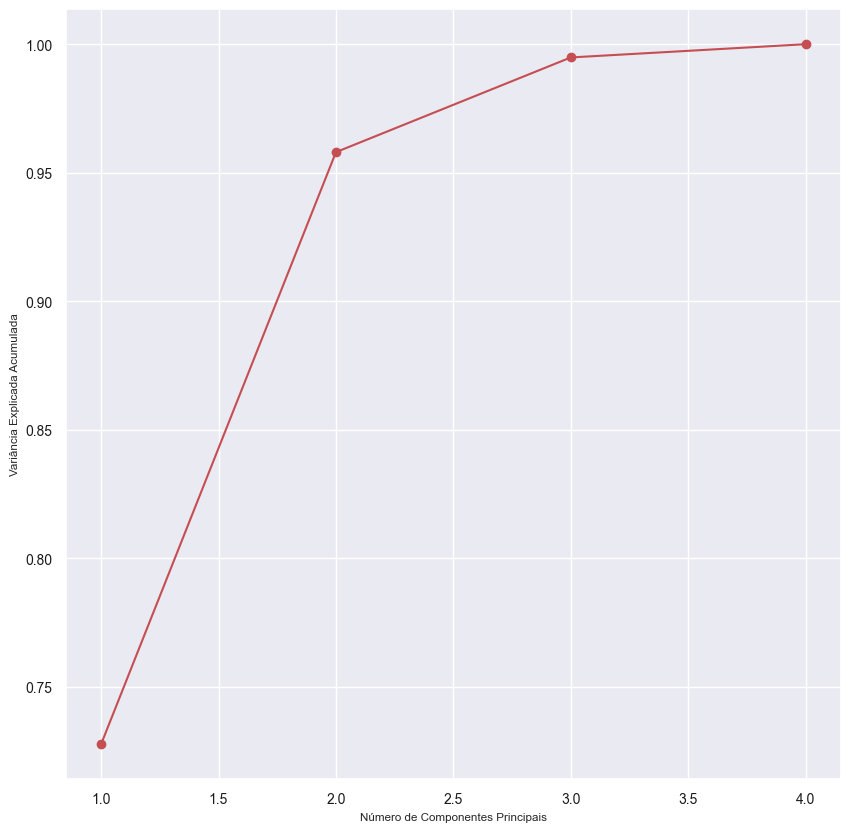

In [187]:
pca = PCA().fit(X)
plt.figure(figsize = (10,10))
ncomp = np.arange(1, np.shape(X)[1]+1)
plt.plot(ncomp, np.cumsum(pca.explained_variance_ratio_), 'ro-')
plt.ylabel("Variância Explicada Acumulada")
plt.xlabel("Número de Componentes Principais")
plt.xticks(color = 'k', fontsize = 10)
plt.yticks(color = 'k', fontsize = 10)	
plt.show()